# Hito 2: Base de datos y analisis inicial.

Analizaremos en un inicio la relacion entre el precio del cobre y la actividad economica chilena, la cual sera medida mediante el Imacec total y sus componentes mineros y no mineros.
Este análisis es la continuacions de lo planteado en el hito 1 y servirá como base para desarrollar y evaluar pronósticos a 12 meses en etapas posteriores.

## Datos y metodología

Se usaran 12 series obtenidas mediante las APIs del Banco Central de Chile y FRED. El período solicitado va desde enero de 2010 hasta agosto de 2026, con una fecha de corte del 31 de agosto de 2026.

Los datos se almacenaran en la base SQLite `data/coyuntura_hito2.db`. La consulta `sql/06_series_mensuales_hito2.sql` nos permite trabajar con una frecuencia mensual común.

Para el tipo de cambio y la TPM, calcularemos el promedio de las observaciones diarias disponibles por cada mes. Las otras series conservan sus valores mensuales originales.

Las variaciones interanuales del Imacec y del cobre se calculan comparando cada mes con el mismo mes del año anterior. Como la serie de inflación ya se muestra como variación interanual, se utiliza directamente.

Los datos faltantes al inicio de algunas series se mantienen como faltantes. Para comparar las correlaciones con distintos rezagos del cobre, se utiliza una muestra común de 176 meses.

Los resultados corresponden a un análisis previo y no nos permiten demostrar causalidad.

In [1]:
import sys
from pathlib import Path

print("Python utilizado:", sys.executable)
print("Carpeta de trabajo:", Path.cwd())

Python utilizado: c:\Users\benja\OneDrive\Escritorio\PYTHON\kit-inicio-coyuntura\venv\Scripts\python.exe
Carpeta de trabajo: c:\Users\benja\OneDrive\Escritorio\PYTHON\kit-inicio-coyuntura\notebooks


In [2]:
from pathlib import Path
from contextlib import closing
import sqlite3
import pandas as pd

raiz = Path.cwd().parent
ruta_db = raiz / "data" / "coyuntura_hito2.db"
ruta_sql = raiz / "sql" / "06_series_mensuales_hito2.sql"

consulta = ruta_sql.read_text(encoding="utf-8")
uri = ruta_db.resolve().as_uri() + "?mode=ro"

with closing(sqlite3.connect(uri, uri=True)) as conexion:
    datos = pd.read_sql_query(consulta, conexion, parse_dates=["fecha"])

print("Filas leídas:", len(datos))
print("Indicadores:", datos["id_serie"].nunique())
print("Período:", datos["fecha"].min().date(), "a", datos["fecha"].max().date())

Filas leídas: 2386
Indicadores: 12
Período: 2010-01-01 a 2026-08-01


In [3]:
mensual = datos.pivot(
    index="fecha",
    columns="id_serie",
    values="valor"
).sort_index()

mensual = mensual.asfreq("MS")

faltantes = mensual.isna().sum()

print("Meses:", mensual.shape[0])
print("Indicadores:", mensual.shape[1])
print("\nFaltantes por indicador:")
print(faltantes[faltantes > 0].to_string())

Meses: 200
Indicadores: 12

Faltantes por indicador:
id_serie
F049.DES.TAS.INE9.10.M      2
F074.IPC.V12.Z.EP23.C.M    12


In [4]:
indicadores = pd.DataFrame(index=mensual.index)

imacec = mensual["F032.IMC.IND.Z.Z.EP18.Z.Z.0.M"]
cobre = mensual["F019.PPB.PRE.40.M"]

indicadores["imacec_aa"] = 100 * (imacec / imacec.shift(12) - 1)
indicadores["cobre_aa"] = 100 * (cobre / cobre.shift(12) - 1)

indicadores["inflacion_aa"] = mensual["F074.IPC.V12.Z.EP23.C.M"]
indicadores["tpm_promedio"] = mensual["F022.TPM.TIN.D001.NO.Z.D"]

print(indicadores.tail(6).round(2).to_string())

            imacec_aa  cobre_aa  inflacion_aa  tpm_promedio
fecha                                                      
2026-03-01       0.09     28.44           2.8           4.5
2026-04-01      -1.07     40.24           4.0           4.5
2026-05-01      -1.39     41.74           3.9           4.5
2026-06-01       2.02     38.04           4.3           4.5
2026-07-01      -1.49     38.32           3.5           4.5
2026-08-01      -1.01     48.80           4.1           4.5


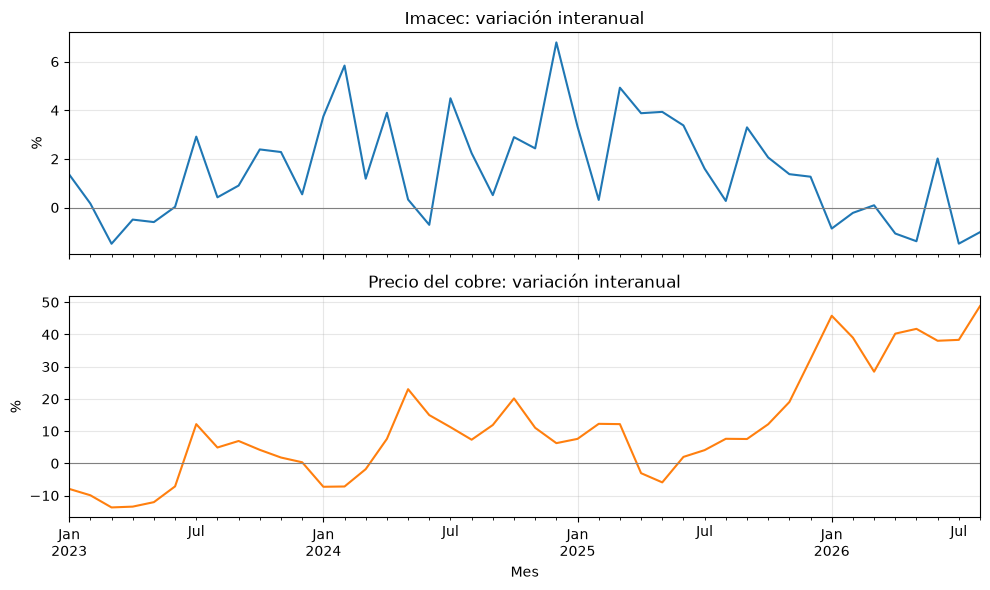

In [5]:
import matplotlib.pyplot as plt

vista = indicadores.loc["2023-01-01":]

fig, ejes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

vista["imacec_aa"].plot(ax=ejes[0], color="tab:blue")
ejes[0].set_title("Imacec: variación interanual")

vista["cobre_aa"].plot(ax=ejes[1], color="tab:orange")
ejes[1].set_title("Precio del cobre: variación interanual")

for eje in ejes:
    eje.axhline(0, color="gray", linewidth=0.8)
    eje.set_ylabel("%")
    eje.grid(alpha=0.3)

ejes[1].set_xlabel("Mes")
fig.tight_layout()

ruta_figuras = raiz / "figuras"
ruta_figuras.mkdir(exist_ok=True)
fig.savefig(
    ruta_figuras / "imacec_cobre_interanual.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Analisis de la actividad economica y precio del cobre

El grafico nos muestra las variaciones interanuales del Imacec y del precio del cobre entre enero del 2023 y agosto del 2026, esto fue calculado con datos del Banco Central de Chile.

En agosto del año 2026, el Imacec bajo en un 1,01% con respecto al mismo mes en el año 2025, mientras que el precio del cobre subio un 48,8%. Durante Marzo-Agosto del 2026, el cobre se mantuvo positivo con las variaciones interanuales, mientras que el Imacec tuvo subidad y bajadas.

Estos resultados nos muestran una divergencia reciente entre ambas series. Para que podamos estudiar esta relacion que hicimos en el Hito 1, vamos a analizar los componentes mineros y no mineros del Imacec y la relacion con el cobre considerando los rezagos. El grafico solo no nos permite decir que existe una relacion causal. 

In [6]:
minero = mensual["F032.IMC.IND.Z.Z.EP18.03.Z.0.M"]
no_minero = mensual["F032.IMC.IND.Z.Z.EP18.N03.Z.0.M"]

indicadores["imacec_minero_aa"] = 100 * (minero / minero.shift(12) - 1)
indicadores["imacec_no_minero_aa"] = 100 * (no_minero / no_minero.shift(12) - 1)

columnas = [
    "imacec_aa",
    "imacec_minero_aa",
    "imacec_no_minero_aa",
    "cobre_aa"
]

print(indicadores[columnas].tail(6).round(2).to_string())

            imacec_aa  imacec_minero_aa  imacec_no_minero_aa  cobre_aa
fecha                                                                 
2026-03-01       0.09             -7.37                 1.25     28.44
2026-04-01      -1.07            -12.78                 0.69     40.24
2026-05-01      -1.39            -12.74                 0.31     41.74
2026-06-01       2.02              8.23                 1.20     38.04
2026-07-01      -1.49             -9.30                -0.31     38.32
2026-08-01      -1.01            -17.37                 1.42     48.80


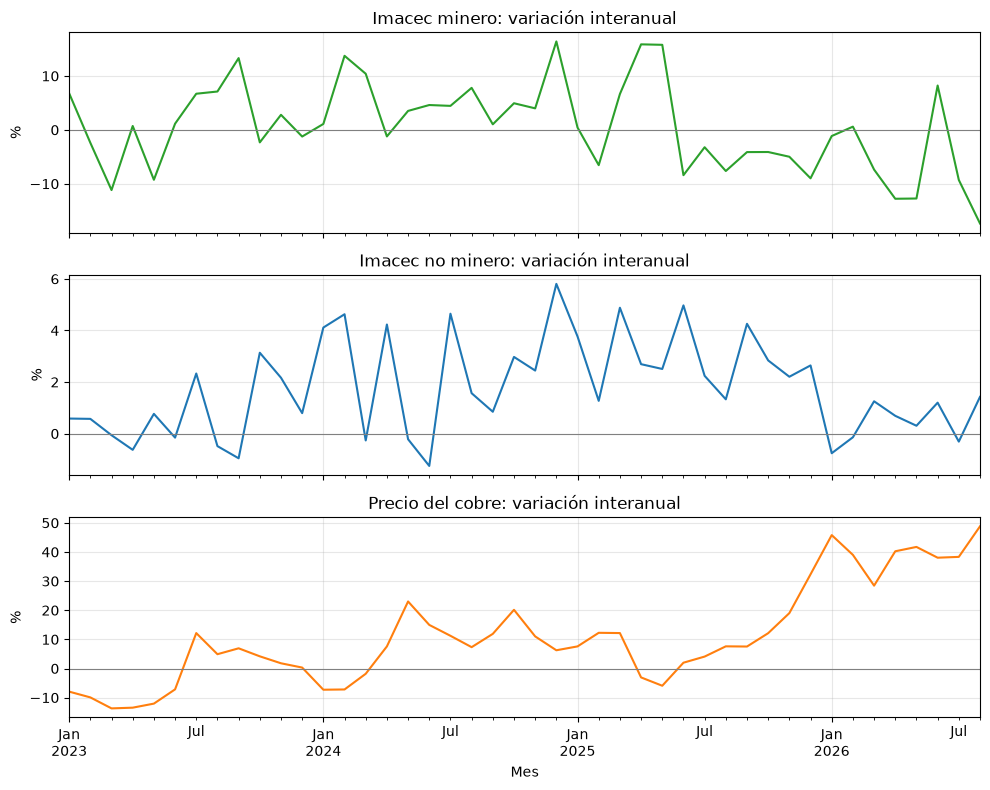

In [7]:
vista = indicadores.loc["2023-01-01":]

fig, ejes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

series = [
    ("imacec_minero_aa", "Imacec minero: variación interanual", "tab:green"),
    ("imacec_no_minero_aa", "Imacec no minero: variación interanual", "tab:blue"),
    ("cobre_aa", "Precio del cobre: variación interanual", "tab:orange"),
]

for eje, (columna, titulo, color) in zip(ejes, series):
    vista[columna].plot(ax=eje, color=color)
    eje.set_title(titulo)
    eje.axhline(0, color="gray", linewidth=0.8)
    eje.set_ylabel("%")
    eje.grid(alpha=0.3)

ejes[2].set_xlabel("Mes")
fig.tight_layout()

fig.savefig(
    ruta_figuras / "imacec_sectores_cobre.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Analisis actividad minera y no minera

En el periodo mostrado, el Imacec minero nos deja ver oscilaciones interanuales mas grandes que el comportamiento no minero.
en agosto del año 2026, la actividad minera bajo en un 17,37% interanual, mientras que la actividad no minera crecio en 1,42%. En este mismo mes, el precio del cobre subio un 48,8% interanual.
El aumento del precio del cobre coexistio con una contraccion
de la actividad minera. Para analizar profundamente la relación planteada
en el hito 1, veremos si las variaciones del cobre en meses
previos se asocian con el crecimiento posterior del Imacec.

In [8]:
actividades = [
    "imacec_aa",
    "imacec_minero_aa",
    "imacec_no_minero_aa"
]

base_rezagos = indicadores[actividades].copy()

for rezago in range(13):
    base_rezagos[f"cobre_rezago_{rezago}"] = indicadores["cobre_aa"].shift(rezago)

base_rezagos = base_rezagos.dropna()

filas = []

for rezago in range(13):
    fila = {
        "rezago_meses": rezago,
        "n_pares": len(base_rezagos)
    }

    for actividad in actividades:
        fila[actividad] = base_rezagos[actividad].corr(
            base_rezagos[f"cobre_rezago_{rezago}"]
        )

    filas.append(fila)

correlaciones = pd.DataFrame(filas)

print(correlaciones.round(3).to_string(index=False))

 rezago_meses  n_pares  imacec_aa  imacec_minero_aa  imacec_no_minero_aa
            0      176      0.344            -0.088                0.370
            1      176      0.428            -0.085                0.453
            2      176      0.463            -0.129                0.497
            3      176      0.463            -0.191                0.510
            4      176      0.457            -0.162                0.502
            5      176      0.453            -0.078                0.487
            6      176      0.425            -0.053                0.456
            7      176      0.393            -0.055                0.424
            8      176      0.357            -0.088                0.395
            9      176      0.326            -0.114                0.369
           10      176      0.294            -0.117                0.337
           11      176      0.249            -0.135                0.293
           12      176      0.194            -0.132

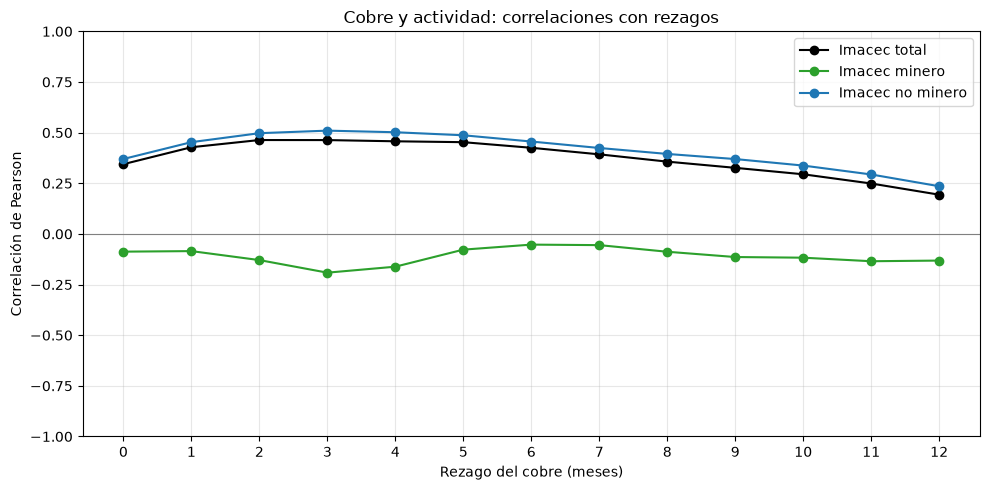

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

curvas = [
    ("imacec_aa", "Imacec total", "black"),
    ("imacec_minero_aa", "Imacec minero", "tab:green"),
    ("imacec_no_minero_aa", "Imacec no minero", "tab:blue"),
]

for columna, nombre, color in curvas:
    ax.plot(
        correlaciones["rezago_meses"],
        correlaciones[columna],
        label=nombre,
        color=color,
        marker="o"
    )

ax.axhline(0, color="gray", linewidth=0.8)
ax.set_ylim(-1, 1)
ax.set_xticks(range(13))
ax.set_xlabel("Rezago del cobre (meses)")
ax.set_ylabel("Correlación de Pearson")
ax.set_title("Cobre y actividad: correlaciones con rezagos")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(
    ruta_figuras / "correlaciones_cobre_rezagos.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Relación entre el cobre y la actividad económica con rezagos

Calculamos las correlaciones entre las variaciones interanuales del precio del cobre y del Imacec, usando una muestra común de 176 meses. EL rezago de tres meses compara la actividad de un mes con la variación del cobre registrada tres meses antes.

El Imacec total presenta sus mayores correlaciones alrededor de los rezagos de dos y tres meses, aproximadamente de 0,463. El Imacec no minero alcanza su mayor correlación en el rezago de tres meses, con un valor de 0,510.

Pero, las correlaciones del Imacec minero son negativas y de baja magnitud en todos los rezagos vistos. En esta muestra, la asociación positiva con el cobre es más marcada para la actividad no minera que para la minera.

Estos resultados aun no son tajantes. Las correlaciones no demuestran causalidad ni nos permiten asegurar que el cobre mejore los pronósticos. Esa posibilidad debe evaluarse luego con modelos y validación fuera de muestra.

## Conclusion inicial.

En agosto de 2026, el Imacec total bajo un 1,01 % interanual. Sus componentes nos mostraron comportamientos diferentes: el Imacec minero bajo un 17,37 %, mientras que el no minero subio un 1,42 %. Durante el mismo mes, el precio del cobre subio un 48,8 % interanual.

Estos resultados nos muestran que el aumento del precio del cobre puede coexistir con una disminución de la actividad minera. Entonces, la relación planteada en el hito 1 necesita examinar distintos componentes de la actividad y considerar rezagos.

En la muestra que analizamos, las correlaciones positivas con el cobre fueron mayores para el Imacec no minero, especialmente con un rezago de 3 meses. El componente minero nos mostro correlaciones negativas de baja magnitud.

Esta evidencia nos permite orientar el análisis que tendremos despues, pero no demuestra causalidad ni capacidad predictiva. Para que podamos responder la pregunta de investigación, es necesario comparar modelos y evaluar sus pronósticos fuera de muestra, manteniendo el horizonte de doce meses que propusimos en el hito 1.